<a href="https://colab.research.google.com/github/roser740/Data-Analytics/blob/main/TASQUES%20S9/TS9_01_roser_carrera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Tasca S9.01. Visualització de Dades amb Python i Power BI**

En aquest sprint treballaràs la interpretació analítica i el storytelling basat en dades, podràs utilitzar la base de dades que tens disponible a BigQuery o bé la base de dades creada amb MySQL al Sprint 2, a partir de l’exercici 8, i aprendràs a construir visualitzacions en Python com a alternativa programàtica a les eines de BI.

L'objectiu és aprendre a generar gràfics en Python i utilitzar-los per respondre preguntes de negoci. A més, hauràs de justificar les decisions preses i comunicar els resultats de manera clara i argumentada.

El teu paper com a analista serà:

» Entendre què se t'està preguntant des del punt de vista del negoci.

» Decidir quines visualitzacions són adequades per respondre cada pregunta.

» Construir aquestes visualitzacions en Python.

» Interpretar correctament què mostren les dades.

» Detectar possibles biaixos, limitacions o riscos en l'anàlisi.

» Proposar accions de negoci fonamentades en dades.

Aquest sprint posa l'èmfasi en l'ús de Python com a eina d'anàlisi visual, en el criteri analític i en la capacitat de transformar gràfics en decisions, més que en la sofisticació tècnica. Procura que el teu codi sigui clar i organitzat.

# **📚 Connexió amb MySQL**

Per connectar Google Colab amb MySql hem seguit els següents passos:
1. Instal·lació de Jupyter Notebook des del terminal: *py -m pip install notebook*
2. Iniciació del pont local des del terminal: *py -m notebook --no-browser --NotebookApp.allow_origin="https://colab.research.google.com" --NotebookApp.allow_credentials=True --port=8888 --NotebookApp.port_retries=0*
3. Connexió de Google Colab a un entorn d'execució local
4. Comprovació de la connexió local:



In [153]:
import os
import socket
import sys

print("Equip:", socket.gethostname())
print("Python:", sys.executable)
print("Usuari:", os.getenv("USERNAME") or os.getenv("USER"))

Equip: DESKTOP-M6GB2OT
Python: C:\Users\PC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe
Usuari: PC


5. Instal·lació de les llibreries per poder connectar amb MySQL: *%pip install sqlalchemy pymysql*
6. Configuració de la connexió amb MySQL i comprovació:


In [154]:

import pymysql
from sqlalchemy import create_engine

# Substitueix pels teus valors de credencials de MySQL local
USER = "root"  # p. ex. 'root'
PASSWORD = "Cabestany26$"
HOST = "127.0.0.1"
PORT = 3306  # Port
DATABASE = "vendes"

# Opció amb SQLAlchemy (Recomanada)
connection = (f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}")
engine = create_engine(connection)

# Comprovar connexió
with engine.connect() as conn:
    print("Connexió establerta correctament amb SQLAlchemy!")

Connexió establerta correctament amb SQLAlchemy!


7. Comprovació de lectura d'una taula de MySQL:

In [159]:
# Llegir dades amb Pandas
df = pd.read_sql("SELECT * FROM companies LIMIT 10;", con=engine)
display(df.head())

,company_id,company_name,phone,email,country,website,merchant_category,merchant_price_position
0,b-2222,Ac Fermentum Incorporated,+64 601 244 6320,donec.porttitor.tellus@yahoo.net,Germany,https://www.ac-fermentum-incorporated.com,Beauty,mid-market
1,b-2226,Magna A Neque Industries,+33 823 560 3779,risus.donec.nibh@icloud.org,Australia,https://www.magna-a-neque-industries.com,Travel,budget
2,b-2230,Fusce Corp.,+29 657 646 4324,risus@protonmail.edu,United States,https://www.fusce-corp.com,Home,mid-market
3,b-2234,Convallis In Incorporated,+6 693 982 1255,mauris.ut@aol.couk,Germany,https://www.convallis-in-incorporated.com,Sports,mid-market
4,b-2238,Ante Iaculis Nec Foundation,+69 914 549 1009,sed.dictum.proin@outlook.ca,New Zealand,https://www.ante-iaculis-nec-foundation.com,Toys,mid-market


# **📚 Llibreries**

Abans d'importar les llibreries les hem instal·lat a l'entorn local seguint les següents instruccions:

%pip install pandas

%pip install matplotlib

%pip install seaborn

Un cop fet això ja podem importar les llibreries que necessitem per fer els exercicis:


In [90]:
import pandas as pd
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

import seaborn as sns
import seaborn.objects as so

plt.close("all")

# **♻ Re-utilització de funcions:**

Utilitzarem funcions que tenim definides d'altres esprints.

In [91]:
def mostrar_dataframe(df, títol):
#Presenta les dades en format tabular amb el títol indicat

    # Mostrem títol
    print("\n" + "="*100)
    print(títol)
    print("="*100)
    # La funció display mostra les dades del dataframe en format taula.
    # Utilitzem la propietat style per amagar la columna de l'índex.
    display(df)

# **Nivell 1 - Visualització analítica guiada en Python**


L'objectiu del nivell és aplicar criteri analític per respondre preguntes de negoci mitjançant visualitzacions en Python, treballant amb les taules del model del Sprint 2 a partir de l’exercici 8, carregades com a DataFrame independents.

En aquest nivell no es demana construir un dataset final ni unificar totes les taules, sinó:

» Identificar quina informació és necessària.

» Escollir correctament la taula (o taules) rellevant(s).

» Construir visualitzacions adequades.

» Interpretar els resultats obtinguts.

Aquest nivell posa l'èmfasi en pensar abans de programar.

# **Exercici 1: Preguntes analítiques directes (sense integracions complexes)**

🌍 **Context:** Es treballa amb una sola taula a la vegada, escollida segons la pregunta analítica. No cal fer merge entre taules ni definir funcions avançades.

**Aspectes a revisar i analitzar:**

» Identificar quina informació és necessària. Quin DataFrame és el més adequat per respondre la pregunta.

» Escollir correctament la taula (o taules) rellevant(s).

» Tipus de variables implicades.

» Elecció del tipus de gràfic.

**Preguntes analítiques:**(només utilitzant la taula de transaccions) :

1. Com evoluciona el nombre de transaccions al llarg del temps? Exemple de passos guiats amb pandas.
    *   Selecciona la columna temporal adequada.
    *   Defineix el nivell temporal d'anàlisi.
    *   Compta el nombre de registres per període temporal.
    *   Ordena els resultats cronològicament.
    *   Visualitza l'evolució amb un gràfic de línies amb pandas.

2. Quins usuaris generen més volum de facturació? Exemple de passos guiats amb seaborn.
    *   Identifica la columna que representa el usuari.
    *   Agrupa les transaccions per usuari i calcula el volum total de facturació sumant la columna amount.
    *   Ordena els usuaris de major a menor volum de facturació.
    *   Selecciona els N usuaris principals (per exemple, els 15 primers).
    *   Representa el resultat mitjançant un gràfic de barres utilitzant Seaborn

3. Hi ha diferències en la distribució de l'import de les transaccions segons l'hora del dia i si han estat acceptades o rebutjades? Exemple de passos guiats amb seaborn.
    *   Crea una nova columna amb l'hora del dia a partir del timestamp.
    *   Utilitza un violinplot de seaborn per analitzar la distribució dels imports.
    *   Assigna: x per l'hora del dia, y per l'import de la transacció i hue per l'estat de la transacció.
    *   Activa split per comparar acceptades i rebutjades i inner amb quartile per mostrar mediana i quartils.

4. Quins dies de la setmana es concentra més activitat de venda?

👉 **Per a cada pregunta:**

  *   Construeix una visualització senzilla en Python sense utilitzar IA.
  *   Interpreta breument el resultat obtingut.
  *   Utilitza les eines d'IA disponibles a Colab per proposar una visualització alternativa.
  *   Compara el resultat inicial amb el resultat proposat per la IA i valora críticament si la nova proposta és una millora o un empitjorament, justificant la teva decisió

# **Disseny i implementació de la solució**

## 🧠 **Algoritme inicial**

1. Evolució de les transaccions al llarg del temps.

2. Top 15 de volum de facturació per usuari

3. Distribució de l'import segons l'hora i l'estat.

4. Distribució de la venda segons el dia de la setmana.

## **💢 Estructures de dades**

Carreguem en un dataframe la taula ***transactions*** de la base de dades ***vendes*** que tenim a MySQL. Mostrem la informació dels tipus de camps i una mostra de les dades que ens anirà bé per resoldre els exercicis.

In [94]:
df_trans = pd.read_sql("SELECT * FROM transactions;", con=engine)
df_trans.info()
mostrar_dataframe (df_trans.head(), "MOSTRA DEL DATAFRAME DE TRANSACCIONS")

<class 'pandas.DataFrame'>
RangeIndex: 99999 entries, 0 to 99998
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                99999 non-null  str           
 1   card_id           99999 non-null  str           
 2   business_id       99999 non-null  str           
 3   timestamp         99999 non-null  datetime64[us]
 4   amount            99999 non-null  float64       
 5   declined          99999 non-null  int64         
 6   product_ids       99999 non-null  str           
 7   user_id           99999 non-null  int64         
 8   lat               99999 non-null  float64       
 9   longitude         99999 non-null  float64       
 10  discount_amount   99999 non-null  float64       
 11  tax_amount        99999 non-null  float64       
 12  shipping_amount   99999 non-null  float64       
 13  channel           99999 non-null  str           
 14  campaign_id       99999 non-null 

,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,discount_amount,tax_amount,shipping_amount,channel,campaign_id,device_type,is_international,decline_reason,distance_km
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,34.17,72.25,0.00,online,SUMMER_TRAVEL,mobile,0,,59.95
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.7573,-95.37960,16.10,22.47,0.00,store,SUMMER_TRAVEL,pos,1,,1157.10
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,175.00,0,72,2115,53.5489,-113.50300,1.05,14.45,0.00,store,NO_CAMPAIGN,pos,0,,540.32
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,158.55,0,18,3025,52.2084,5.69081,25.31,25.96,8.99,marketplace,WINTER_SALE,desktop,0,,28.52
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,CcU-3358,b-2598,2023-09-23 04:51:43,317.97,0,"35, 33, 19",215,53.5535,-113.49900,2.87,26.25,0.00,store,NO_CAMPAIGN,pos,0,,539.82


## 🧩 **Implementació**

### ***1. Evolució de les transaccions al llarg del temps***


1. Com evoluciona el nombre de transaccions al llarg del temps?
    *   Selecciona la columna temporal adequada.
    *   Defineix el nivell temporal d'anàlisi.
    *   Compta el nombre de registres per període temporal.
    *   Ordena els resultats cronològicament.
    *   Visualitza l'evolució amb un gràfic de línies amb pandas.

🟢**Visualització**      🔴🟠🔵🟣🟡🟤⚫⚪🟥🟧🟨🟩🟦🟪🟫⬛⬜

Per veure com evoluciona el nombre de transaccions al llarg del temps utilitzem el dataframe de transaccions:
*   Utilitzem la columna **timestamp** que guarda la data i hora de cada transacció per extreure l'any i comptar els número de transaccions realitzades cada any. Ordenem per índex per poder mostrar els resultats cronològicament.
*   Seleccionem les transaccions amb **declined = 0** ja que suposem que interessa valorar les transaccions acceptades i no les rebutjades. El fet de parlar de transaccions sense especificar crea una mica de confusió.
*   Visualitzem amb un **gràfic** de línies utilitzant les instruccions de matplotlib.



In [184]:
# GENERACIÓ DE LES DADES ##########################################

anys = df_trans[df_trans['declined']==0]['timestamp'].dt.year.value_counts().sort_index()

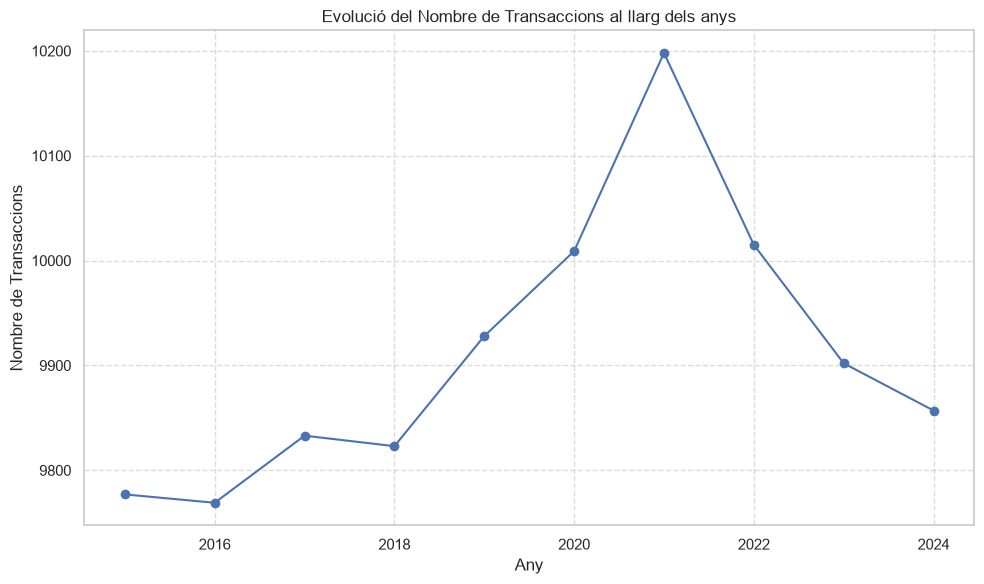

In [186]:
# GENERACIÓ DEL GRÀFIC ##########################################

# Defninim la mida del gràfic
plt.figure(figsize=(10, 6))
# Generem un gràfic de línies
anys.plot(kind='line', marker='o')
# Mostrem títol i etiquetes dels eixos
plt.title('Evolució del Nombre de Transaccions al llarg dels anys')
plt.xlabel('Any')
plt.ylabel('Nombre de Transaccions')
# Mostrem graella del fons
plt.grid(True, linestyle='--', alpha=0.7)
# Ajustem marges i espais del gràfic
plt.tight_layout()
plt.show()

🟢**Interpretació**  


Aquest gràfic de línies mostra l'evolució del nombre de transaccions al llarg dels anys des del 2015 al 2024.

En aquest gràfic observem:
*   un **creixement** del nombre de transaccions des del 2015 al 2021. El creixement és més suau els primers anys i més pronunciat a partir del 2018.
*   a l'any 2021 el nombre de transaccions assoleix un **valor màxim** d'aproximadament 10200 transaccions.
*   a partir de l'any 2021 hi ha un **decreixement** del nombre de transaccions fins a assolir l'any 2024 valors propers a l'any 2019.

Tot i que visualment sembla que el creixement i el decreixement són molt grans cal tenir en compte l'escala de l'eix vertical. Veiem que els valors no comencen des de 0. Així la diferència entre el valor més baix i el més alt és d'un 4% aproximadament.



🟢**Visualització alternativa amb IA**  

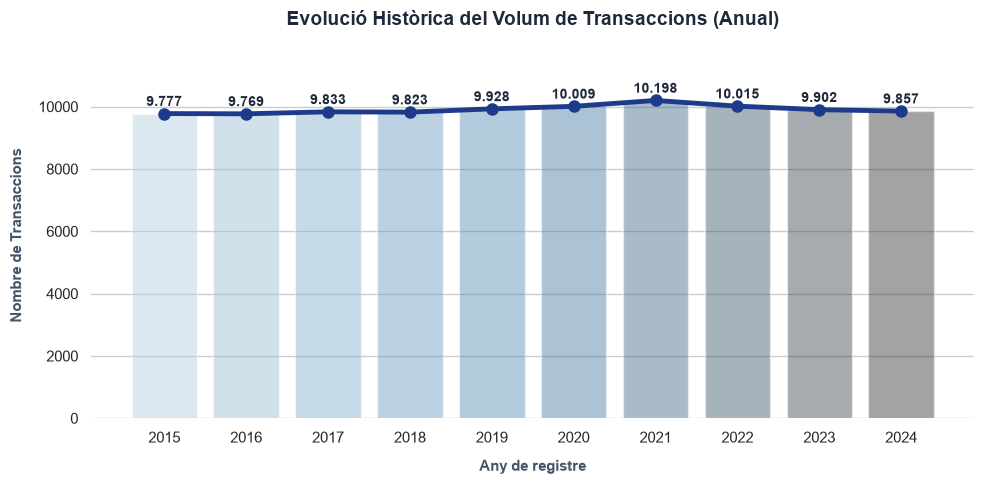

In [166]:
# Calculem el nombre de transaccions per any
anys_vendes = df_trans[df_trans['declined']==0]['timestamp'].dt.year.value_counts().sort_index().reset_index(name='transaccions')
anys_vendes.columns = ['Any', 'Transaccions']

# Configurem un disseny visual molt més net i professional
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Creem un gràfic de barres elegant de fons per donar context de volum
ax = sns.barplot(
    data=anys_vendes,
    x='Any',
    y='Transaccions',
    palette='Blues_d',
    alpha=0.45,
    hue='Any',
    legend=False
)

# Superposem la línia de tendència de color intens per marcar l'evolució clarament
plt.plot(
    range(len(anys_vendes)),
    anys_vendes['Transaccions'],
    color='#1e3a8a',
    linewidth=3.5,
    marker='o',
    markersize=8,
    label='Tendència'
)

# Afegim etiquetes amb els valors a sobre de cada punt per a una lectura ràpida
for i, valor in enumerate(anys_vendes['Transaccions']):
    plt.text(
        i,
        valor + (max(anys_vendes['Transaccions']) * 0.015),
        f"{valor:,}".replace(',', '.'),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#1e293b'
    )

# Personalització de títols i eixos
plt.title('Evolució Històrica del Volum de Transaccions (Anual)', fontsize=14, fontweight='bold', pad=20, color='#1e293b')
plt.xlabel('Any de registre', fontsize=11, fontweight='bold', labelpad=10, color='#475569')
plt.ylabel('Nombre de Transaccions', fontsize=11, fontweight='bold', labelpad=10, color='#475569')

# Ajustos finals de neteja visual
plt.ylim(0, max(anys_vendes['Transaccions']) * 1.15)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

🟢**Comparació**  

Gemini ens proposa com a alternativa un diagrama de barres amb un gràfic de línies superposat.

Aquest gràfic representa una millora respecte a l'anterior en termes de rigor analític i de comunicació de dades (Data Storytelling) concretament en els següents aspectes:
*   **L'eix y comença des de 0**. Això permet apreciar la magnitud real de les dades: el volum de transaccions és extremadament estable al llarg dels 10 anys, amb variacions mínimes entre el punt més baix i el més alt. Evita transmetre una falsa sensació de volatilitat o crisi.
*   **Etiquetes de dades**. Inclou la xifra exacta a la part superior de cada barra/punt. Aquest fet millora la legibilitat immediata i evita que l'usuari hagi de fer estimacions visuals.
*   Suporposa un **gràfic de línies** a les barres que, tot i ser redundant, mostra més clarament l'evolució.

D'altra banda la utilització d'una seqüència de **colors degradats** a les barres crea una mica de confusió ja que pot semblar que les barres més fosques corresponen a un valor més elevat i no és així.




### ***2. Top 15 de volum de facturació per usuari***

2. Quins usuaris generen més volum de facturació?
    *   Identifica la columna que representa el usuari.
    *   Agrupa les transaccions per usuari i calcula el volum total de facturació sumant la columna amount.
    *   Ordena els usuaris de major a menor volum de facturació.
    *   Selecciona els N usuaris principals (per exemple, els 15 primers).
    *   Representa el resultat mitjançant un gràfic de barres utilitzant Seaborn

🟢**Visualització**  

Per veure quins usuaris generen més volum de facturació utilitzem el dataframe de transaccions:
*   Agrupem per la columna **user_id** que guarda el codi de l'usuari que ha realitzat la transacció.  
*   Seleccionem les transaccions amb **declined = 0** ja que per calcular el volum de facturació només cal tenir en compte les transaccions acceptades.

In [181]:
# GENERACIÓ DE LES DADES ##########################################

usuaris = df_trans[df_trans['declined']==0].groupby(['user_id'])['amount'].sum().sort_values(ascending=False).head(15)
# Convertim a un dataframe de dues columnes
usuaris = usuaris.reset_index(name="facturacio_total")

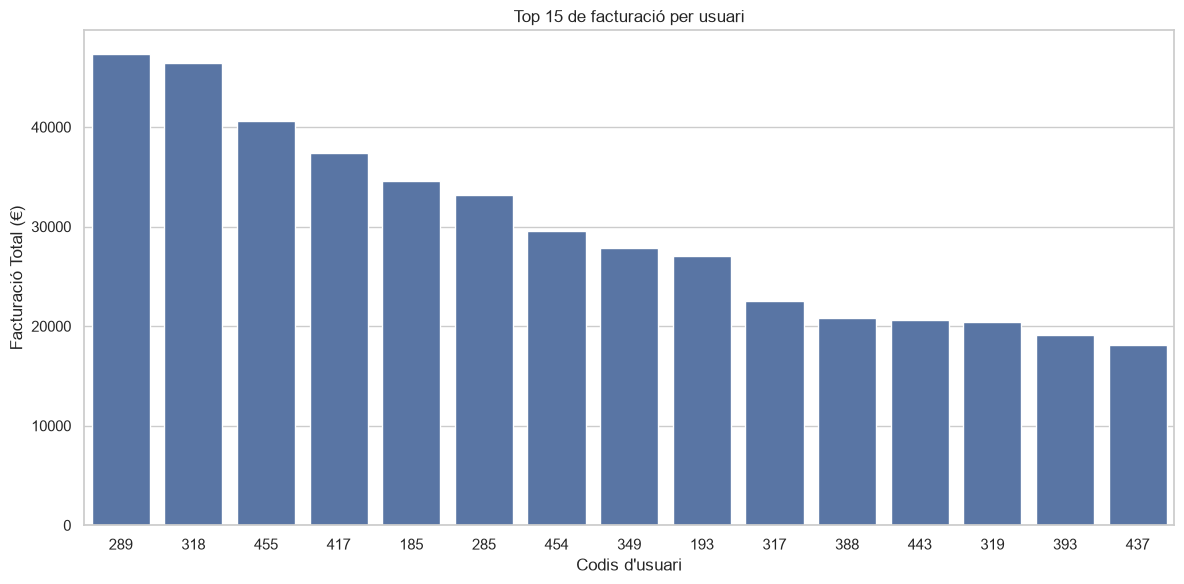

In [180]:
# GENERACIÓ DEL GRÀFIC ##########################################

# Creem i inicialitzem la figura i l'eix principal del gràfic i definim les dimensions del gràfic
fig, ax1 = plt.subplots(figsize=(12, 6))

# Convertim la columna 'user_id' numèrica a tipus categòric de text per evitar ordenacions numèriques automàtiques
usuaris['user_id'] = usuaris['user_id'].astype(str)

# Creem el gràfic de barres mantenint l'ordre del dataframe
sns.barplot(
    data=usuaris,
    x="user_id",
    y="facturacio_total",
    order=usuaris["user_id"],  # Mantenim l'ordre de major a menor facturació
    ax=ax1)

# Mostrem el títol del gràfic i les etiquetes dels eixos
ax1.set_title("Top 15 de facturació per usuari")
ax1.set_ylabel("Facturació Total (€)")
ax1.set_xlabel("Codis d'usuari")

# Ajustem marges i espais del gràfic
plt.tight_layout()
plt.show()

🟢**Interpretació**  

Aquest gràfic de barres mostra el Top 15 d'usuaris que generen més ingressos, ordenats de major a menor segons la seva facturació total en euros.

En aquest gràfic observem:
*   List item
*   Li

El gràfic comença adequadament des de 0 €, evitant distorsions visuals en les proporcions reals.


🟢**Visualització alternativa amb IA**  

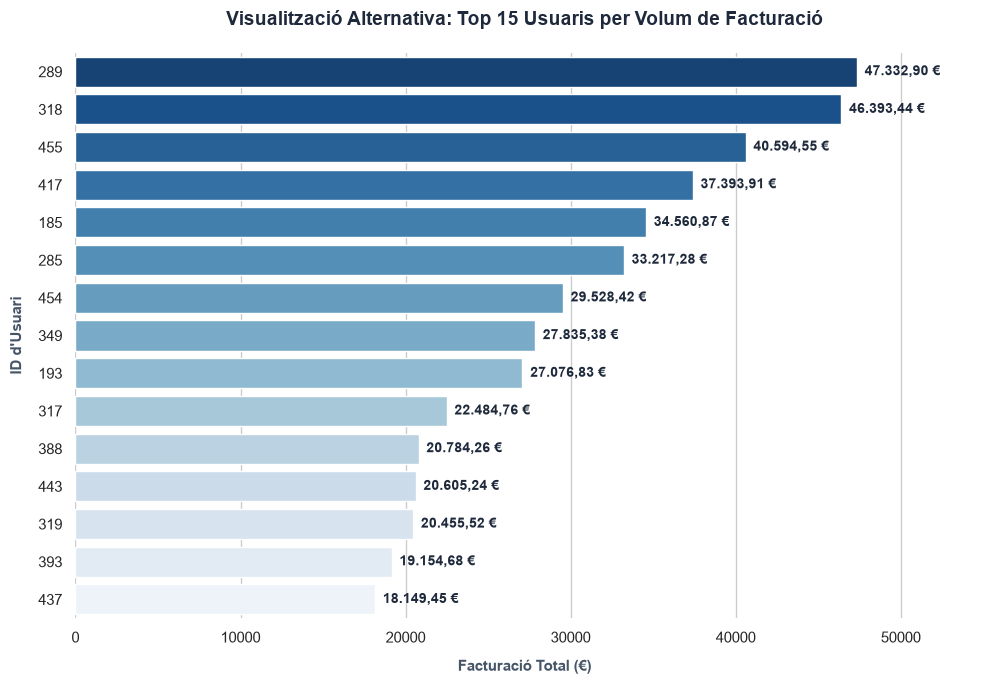

In [176]:


# Preparem les dades del Top 15 (assegurem ID com a text i ordenació correcta)
usuaris_alt = usuaris.copy()
usuaris_alt['user_id'] = usuaris_alt['user_id'].astype(str)
usuaris_alt = usuaris_alt.sort_values(by='facturacio_total', ascending=False)

# Configurem l'estil net i professional
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

# Generem un degradat perfecte de color blau per a 15 barres (de fosc a clar)
colors_degradat = sns.color_palette("Blues_r", n_colors=15)

# Creem el gràfic de barres horitzontals
ax = sns.barplot(
    data=usuaris_alt,
    y="user_id",
    x="facturacio_total",
    order=usuaris_alt["user_id"],
    palette=colors_degradat,
    hue="user_id",
    legend=False
)

# Afegim els valors exactes de facturació al final de cada barra
for i, valor in enumerate(usuaris_alt['facturacio_total']):
    ax.text(
        valor + (max(usuaris_alt['facturacio_total']) * 0.01),  # Petit marge a la dreta de la barra
        i,                                                     # Posició vertical de la barra
        f"{valor:,.2f} €".replace(',', 'X').replace('.', ',').replace('X', '.'),  # Format de moneda en català
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#1e293b'
    )

# Personalitzem els eixos i el títol
plt.title("Visualització Alternativa: Top 15 Usuaris per Volum de Facturació", fontsize=14, fontweight='bold', pad=20, color='#1e293b')
plt.xlabel("Facturació Total (€)", fontsize=11, fontweight='bold', labelpad=10, color='#475569')
plt.ylabel("ID d'Usuari", fontsize=11, fontweight='bold', labelpad=10, color='#475569')

# Ampliem el límit de l'eix X per allotjar còmodament les etiquetes de text
plt.xlim(0, max(usuaris_alt['facturacio_total']) * 1.15)

# Eliminem les línies del marc que no aporten valor
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

🟢**Comparació**  

He optat per un gràfic de barres horitzontals. Aquest format és ideal per comparar categories (com els IDs d'usuari) perquè permet llegir els identificadors i les etiquetes dels valors de manera molt més natural i neta sense haver de rotar els textos.

### ***3. Distribució de l'import segons l'hora i l'estat***

Hi ha diferències en la distribució de l'import de les transaccions segons l'hora del dia i si han estat acceptades o rebutjades? Exemple de passos guiats amb seaborn.

    *   Crea una nova columna amb l'hora del dia a partir del timestamp.
    *   Utilitza un violinplot de seaborn per analitzar la distribució dels imports.
    *   Assigna: x per l'hora del dia, y per l'import de la transacció i hue per l'estat de la transacció.
    *   Activa split per comparar acceptades i rebutjades i inner amb quartile per mostrar mediana i quartils.

🟢**Visualització**  

<Axes: xlabel='hora', ylabel='amount'>

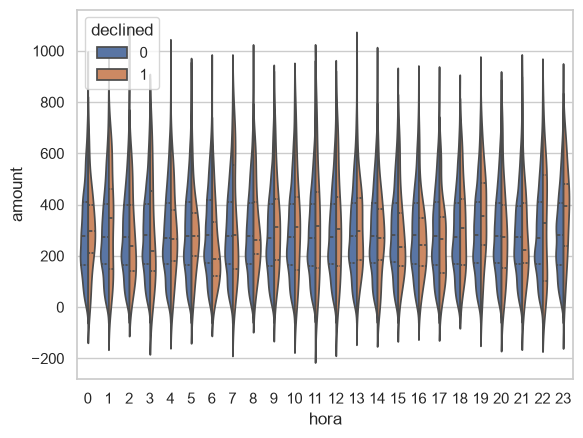

In [141]:
df_trans['hora'] = df_trans['timestamp'].dt.hour
sns.violinplot(x=df_trans['hora'], y=df_trans['amount'],hue=df_trans['declined'], split = True, inner = 'quartile')


🟢**Interpretació**  

🟢**Visualització alternativa amb IA**  

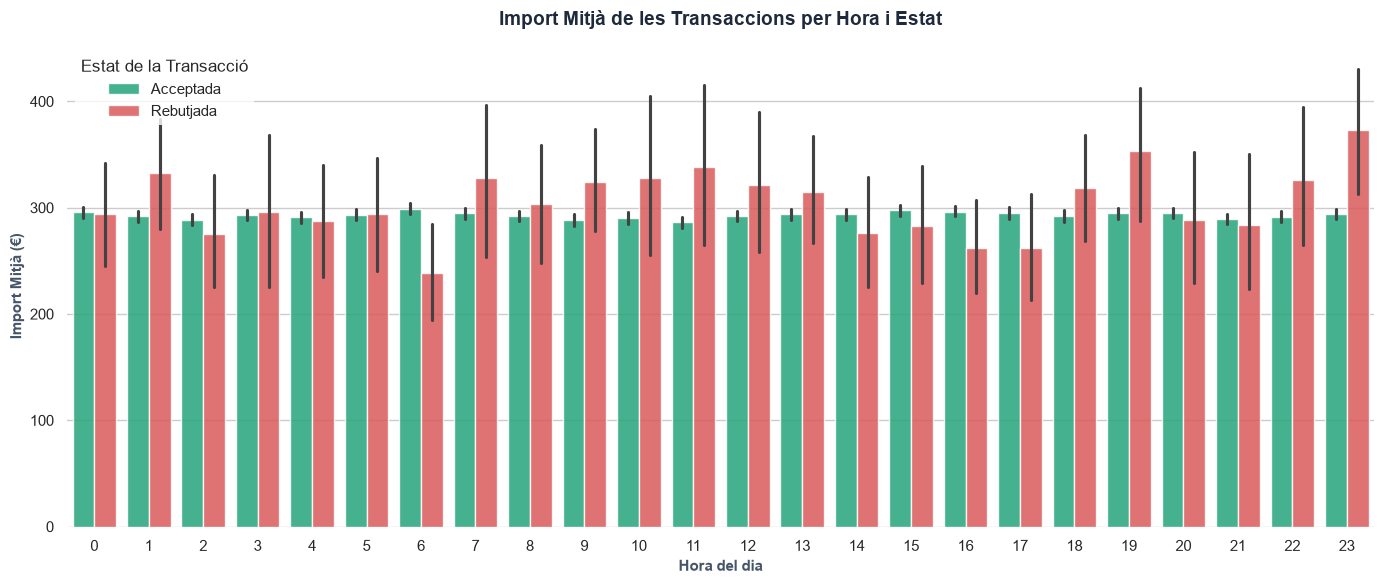

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparem una còpia de les dades per a la visualització
df_hora_estat = df_trans.copy()
df_hora_estat['estat'] = df_hora_estat['declined'].map({0: 'Acceptada', 1: 'Rebutjada'})

# Configurem l'estil visual net
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Creem un gràfic de barres per comparar les mitjanes d'import amb intervals de confiança
ax = sns.barplot(
    data=df_hora_estat,
    x='hora',
    y='amount',
    hue='estat',
    palette={'Acceptada': '#10b981', 'Rebutjada': '#ef4444'},  # Verd per acceptat, Vermell per rebutjat
    alpha=0.85,
    errorbar=('ci', 95)  # Mostra l'interval de confiança del 95% per veure la variabilitat
)

# Personalització de títols i etiquetes
plt.title("Import Mitjà de les Transaccions per Hora i Estat", fontsize=14, fontweight='bold', pad=15, color='#1e293b')
plt.xlabel("Hora del dia", fontsize=11, fontweight='bold', color='#475569')
plt.ylabel("Import Mitjà (€)", fontsize=11, fontweight='bold', color='#475569')

# Llegenda polida
plt.legend(title="Estat de la Transacció", frameon=True, facecolor='white', edgecolor='none')

# Neteja de línies de marc innecessàries
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

🟢**Comparació**  

El gràfic de violí (violinplot) és molt complet perquè mostra tota la densitat de la distribució, però de vegades pot resultar difícil de llegir i interpretar ràpidament per a perfils de negoci.

Com a alternativa senzilla, neta i molt més fàcil de digerir, et proposo un gràfic de barres d'import mitjà per hora, desglossat per l'estat de la transacció (Acceptada vs Rebutjada).

Aquest gràfic inclou línies d'error clares (intervals de confiança) per veure la variabilitat de l'import sense saturar la vista, utilitza colors amb bon contrast i té un disseny molt polit.

### ***4. Distribució de la venda segons el dia de la setmana***

4. Quins dies de la setmana es concentra més activitat de venda?

🟢**Visualització**  

dodge=False: Quan usem hue (per pintar cada dia d'un color de blau diferent), Seaborn pressuposa que hi pot haver múltiples barres agrupades per a un mateix dia i buida l'espai del voltant, fent-les fines. Desactivant el dodge, es dibuixen ocupant tot el seu espai disponible.

width=0.7: Ens permet controlar de forma exacta el gruix perquè no quedin ni massa aferrades ni massa primes, deixant una separació estètica ideal.

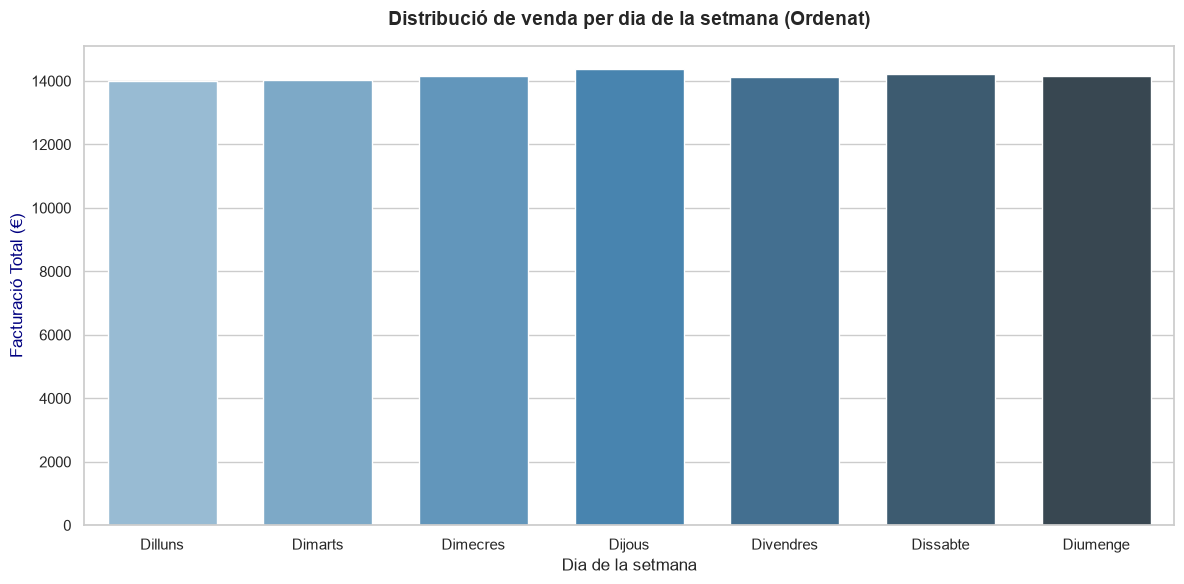

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Creem la columna del nom del dia en anglès
df_trans['dia'] = df_trans['timestamp'].dt.day_name()

# 2. Agrupem i comptem transaccions acceptades
tiquets_per_dia = df_trans[df_trans['declined'] == 0].groupby(['dia'])['id'].count().reset_index(name="facturacio_total")

# 3. Definim l'ordre lògic setmanal
ordre_dies_en = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
traduccion_dies = {
    'Monday': 'Dilluns',
    'Tuesday': 'Dimarts',
    'Wednesday': 'Dimecres',
    'Thursday': 'Dijous',
    'Friday': 'Divendres',
    'Saturday': 'Dissabte',
    'Sunday': 'Diumenge'
}

# Convertim la columna 'dia' a tipus categòric ordenat
tiquets_per_dia['dia'] = pd.Categorical(tiquets_per_dia['dia'], categories=ordre_dies_en, ordered=True)
tiquets_per_dia = tiquets_per_dia.sort_values('dia')

# Mapegem els noms dels dies al català per a la visualització final
tiquets_per_dia['dia'] = tiquets_per_dia['dia'].map(traduccion_dies)

# 4. Creem el gràfic corregit
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# MODIFICACIÓ: S'afegeix dodge=False per evitar que les columnes quedin massa primes
sns.barplot(
    data=tiquets_per_dia,
    x="dia",
    y="facturacio_total",
    ax=ax1,
    palette='Blues_d',
    hue="dia",
    dodge=False,  # <-- EVITA QUE LES COLUMNES ES FACIN PRIMES
    width=0.7     # <-- CONTROLA L'AMPLADA DE LES BARRES (0.7 és ideal)
)

# Personalització d'etiquetes
ax1.set_ylabel("Facturació Total (€)", color="navy", fontsize=12)
ax1.set_xlabel("Dia de la setmana", fontsize=12)
ax1.set_title("Distribució de venda per dia de la setmana (Ordenat)", fontsize=14, pad=15, fontweight='bold')

plt.tight_layout()
plt.show()

🟢**Interpretació**  

🟢**Visualització alternativa amb IA**  

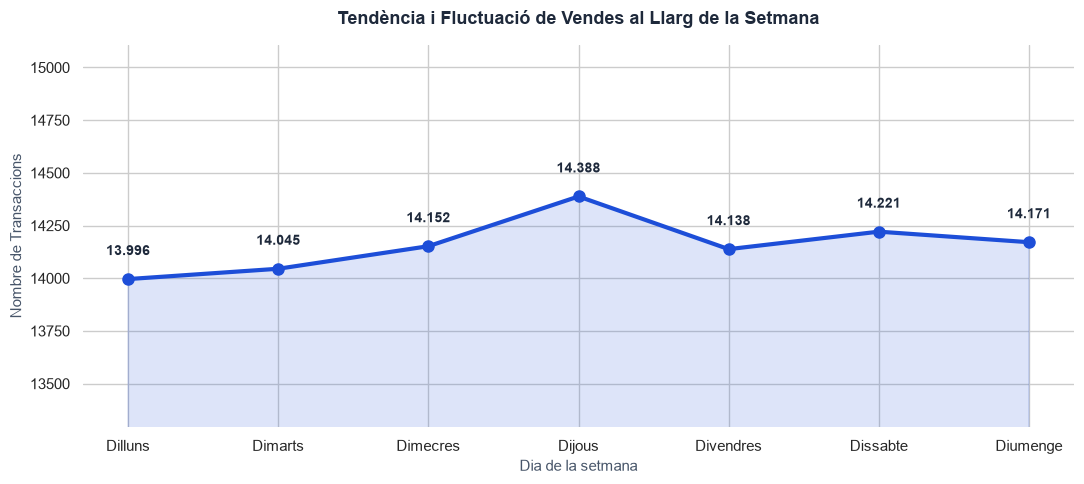

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns

# Preparem les dades ordenades de dilluns a diumenge
df_linia = tiquets_per_dia.copy()

# Configurem l'estil net i professional
plt.figure(figsize=(11, 5))
sns.set_theme(style="whitegrid")

# 1. Dibuixem la línia de tendència principal
plt.plot(
    df_linia['dia'],
    df_linia['facturacio_total'],
    color='#1d4ed8',      # Blau corporatiu intens
    linewidth=3,
    marker='o',
    markersize=8,
    label='Transaccions'
)

# 2. Afegim un ombrejat suau a sota de la línia per donar sensació de volum d'activitat
plt.fill_between(
    df_linia['dia'],
    df_linia['facturacio_total'],
    color='#1d4ed8',
    alpha=0.15
)

# 3. Etiquetem directament els punts clau per evitar que l'usuari hagi de mirar constantment l'eix Y
for i, valor in enumerate(df_linia['facturacio_total']):
    plt.text(
        i,
        valor + 100,
        f"{valor:,}".replace(',', '.'),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#1e293b'
    )

# Personalització final estètica
plt.title("Tendència i Fluctuació de Vendes al Llarg de la Setmana", fontsize=13, fontweight='bold', pad=15, color='#1e293b')
plt.xlabel("Dia de la setmana", fontsize=11, color='#475569')
plt.ylabel("Nombre de Transaccions", fontsize=11, color='#475569')

# Ajustem l'escala de l'eix Y per deixar espai a les etiquetes
plt.ylim(min(df_linia['facturacio_total']) * 0.95, max(df_linia['facturacio_total']) * 1.05)

# Eliminem línies de contorn innecessàries
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

🟢**Comparació**  

Per a l'Exercici 4 (Distribució de la venda segons el dia de la setmana), una alternativa molt elegant, neta i diferent del clàssic gràfic de barres verticals és un gràfic de línia de tendència setmanal o un gràfic de barres horitzontals minimalista.

He generat una proposta de gràfic de línia de tendència contínua (amb un gradient d'àrea ombrejada a sota). Aquesta alternativa és excel·lent per a dades temporals o cícliques (com els dies de la setmana), ja que ajuda l'ull humà a veure instantàniament si l'activitat puja o baixa al llarg de la setmana (de dilluns a diumenge).

## ⭕ **Algoritme principal**

## ▶ **Execució**

# **Exercici 2: Preguntes analítiques complexes (amb guia)**

🌍 **Context:** Aquest exercici requereix combinar informació de diverses taules del model per poder respondre correctament les preguntes.

**Aquí sí que serà necessari:**

» Fer merge entre taules.

» Utilitzar groupby, pivot_table, crosstab...

» Aplicar agregacions, transformacions intermèdies i funcions.

**Preguntes analítiques (amb guia general)**

**» Depenem excessivament d'un nombre reduït de països de companyies venedores?**

Passos orientatius:

1. Combinar la informació de transaccions amb la de companyies.

2. Agrupar la facturació per país.

3. Calcular la facturació total generada per cada país.

4. Ordenar els països de major a menor facturació.

5. Calcular el percentatge acumulat sobre el total.

6. Visualitzar.

**» Existeix estacionalitat en les vendes?**

Passos orientatius:

1. Treballar amb dates de transacció.

2. Extreure la informació temporal rellevant (any i mes).

3. Calcular el volum total de vendes (suma de amount) per any i mes.

4. Comparar patrons temporals amb la comparació entre anys. Crea una taula tipus pivot.

5. Visualitzar l'evolució.

**» Anàlisi de concentració i variabilitat (tria UNA opció)**

**Opció A** – Producte (Només si disposes de la taula de productes)

Quins productes generen més ingressos i amb quina variabilitat?

Passos orientatius:

1. Combinar transaccions, la taula pont i productes.

2. Calcular ingressos per producte amb un groupby, sum y sort.

3. Selecciona els top N productes: 15 per exemple.

4. Escollir una visualització adequada per analitzar dispersió.

**Opció B** – Activitat d'usuaris (Alternativa si no disposes de la taula de productes)

Hi ha usuaris que han deixat de comprar recentment?

Passos orientatius:

1. Identificar l'última compra per usuari.

2. Calcular el temps des de l'última compra.

3. Visualitzar la distribució del temps des de l'última compra.

**» Com varia l'activitat de venda per franges horàries al llarg dels anys? (patrons horaris)**

Passos orientatius:

1. Crear franges horàries a partir de l'hora: crea una funció i aplica-la utilitzant apply.

2. Construir una taula agregada utilitzant crosstab.

3. Visualitzar amb un heatmap.

👉 **Per a cada pregunta:**

» Descriu breument els passos seguits.

» Mostra la visualització final.

» Interpreta què implica per al negoci.

# **Disseny i implementació de la solució**

## 🧠 **Algoritme inicial**

1. Depenem excessivament d'un nombre reduït de països de companyies venedores?

2. Existeix estacionalitat en les vendes?

3. Anàlisi de concentració i variabilitat (tria UNA opció)

4. Com varia l'activitat de venda per franges horàries al llarg dels anys? (patrons horaris).

## **💢 Estructures de dades**

In [92]:
df_comp = pd.read_sql("SELECT * FROM companies;", con=engine)
df_prod = pd.read_sql("SELECT * FROM products;", con=engine)
df_trans_prod = pd.read_sql("SELECT * FROM transaction_products;", con=engine)
df_users = pd.read_sql("SELECT * FROM users;", con=engine)
mostrar_dataframe(df_comp.head(),"MOSTRA DEL DATAFRAME DE COMPANYIES")
mostrar_dataframe(df_prod.head(),"MOSTRA DEL DATAFRAME DE PRODUCTES")
mostrar_dataframe(df_trans_prod.head(),"MOSTRA DEL DATAFRAME DE TRANSACCIONS I PRODUCTES")
mostrar_dataframe(df_users.head(),"MOSTRA DEL DATAFRAME DE USUARIS")


MOSTRA DEL DATAFRAME DE COMPANYIES


,company_id,company_name,phone,email,country,website,merchant_category,merchant_price_position
0,b-2222,Ac Fermentum Incorporated,+64 601 244 6320,donec.porttitor.tellus@yahoo.net,Germany,https://www.ac-fermentum-incorporated.com,Beauty,mid-market
1,b-2226,Magna A Neque Industries,+33 823 560 3779,risus.donec.nibh@icloud.org,Australia,https://www.magna-a-neque-industries.com,Travel,budget
2,b-2230,Fusce Corp.,+29 657 646 4324,risus@protonmail.edu,United States,https://www.fusce-corp.com,Home,mid-market
3,b-2234,Convallis In Incorporated,+6 693 982 1255,mauris.ut@aol.couk,Germany,https://www.convallis-in-incorporated.com,Sports,mid-market
4,b-2238,Ante Iaculis Nec Foundation,+69 914 549 1009,sed.dictum.proin@outlook.ca,New Zealand,https://www.ante-iaculis-nec-foundation.com,Toys,mid-market



MOSTRA DEL DATAFRAME DE PRODUCTES


,id,product_name,price,colour,weight,warehouse_id,category,brand,cost,launch_date
0,1,Direwolf Stannis,161.11,#7c7c7c,1.0,WH-4,Sports,Runway Pro,63.84,2014-11-01
1,2,Tarly Stark,9.24,#919191,2.0,WH-3,Gaming,Questbyte,4.74,2013-02-07
2,3,duel tourney Lannister,171.13,#d8d8d8,1.5,WH-2,Food,Daily Pantry,107.07,2013-08-18
3,4,warden south duel,71.89,#111111,3.0,WH-1,Books,NorthPress,39.17,2013-12-31
4,5,skywalker ewok,171.22,#dbdbdb,3.2,WH-0,Home,NordHaus,83.69,2014-07-17



MOSTRA DEL DATAFRAME DE TRANSACCIONS I PRODUCTES


,id_transaction,id_product
0,001A60EA-DC9C-4E5A-9460-6628B100E7E1,1
1,0032F0BB-BBE6-4AA5-B5EE-EEAD533C0C48,1
2,00342381-503D-422D-85AB-F2D4FFAAD4C7,1
3,004C0A80-E537-46D8-BE44-343D2176DF15,1
4,004D1DB5-B2CB-4460-98B6-31C42CA96E5F,1



MOSTRA DEL DATAFRAME DE USUARIS


,id,name,surname,phone,email,birth_date,country,city,postal_code,address,signup_date,user_segment,income_band
0,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,"Nov 17, 1985",United States,New York,10001,348-7818 Sagittis St.,2014-04-23,young_professional,high
1,2,Garrett,Mcconnell,(718) 257-2412,integer.vitae.nibh@protonmail.org,"Aug 23, 1992",United States,Philadelphia,19101,903 Sit Ave,2014-07-04,young_professional,high
2,3,Ciaran,Harrison,(522) 598-1365,interdum.feugiat@aol.org,"Apr 29, 1998",United States,Houston,77001,736-2063 Tellus St.,2014-02-15,frequent_shopper,high
3,4,Howard,Stafford,1-411-740-3269,ornare.egestas@icloud.edu,"Feb 18, 1989",United States,Phoenix,85001,Ap #545-2244 Erat. Rd.,2014-08-21,premium,high
4,5,Hayfa,Pierce,1-554-541-2077,et.malesuada.fames@hotmail.org,"Sep 26, 1998",United States,Philadelphia,19101,341-2821 Ultrices Av.,2013-04-28,frequent_shopper,high


## 🧩 **Descomponent el problema: naixement de les funcions**

### ***1. Dependència de companyies vendedores***

**» Depenem excessivament d'un nombre reduït de països de companyies venedores?**

Passos orientatius:

1. Combinar la informació de transaccions amb la de companyies.

2. Agrupar la facturació per país.

3. Calcular la facturació total generada per cada país.

4. Ordenar els països de major a menor facturació.

5. Calcular el percentatge acumulat sobre el total.

6. Visualitzar.

🟢**Generació de les dades**  

In [31]:
df_merge = pd.merge(df_trans, df_comp, left_on='business_id', right_on='company_id',how = 'inner')
# inner i left  donen el mateix num de registres. Existeixen totes les companyies
# el grupby ens retorna serie. esborrem index per convertir a dataframe
df_pais = df_merge.groupby(['country'])['amount'].sum().sort_values(ascending=False).reset_index(name="facturacio_total")

# Facturació global total
total_global = df_pais["facturacio_total"].sum()

# Percentatge individual respecte al total
df_pais["per_relatiu"] = (df_pais["facturacio_total"] / total_global) * 100

# Percentatge acumulat (cumsum)
df_pais["per_acumulat"] = df_pais["per_relatiu"].cumsum()

# Resultat en taula
df_pais



,country,facturacio_total,per_relatiu,per_acumulat
0,Sweden,4928117.68,16.822212,16.822212
1,Netherlands,4506571.38,15.383256,32.205468
2,United Kingdom,4099117.08,13.992404,46.197872
3,Italy,4087557.38,13.952945,60.150818
4,Germany,4020364.07,13.723580,73.874397
5,France,1416084.26,4.833827,78.708224
6,United States,1101737.27,3.760798,82.469023
7,Belgium,952208.75,3.250380,85.719403
8,Norway,809288.82,2.762521,88.481924
9,Ireland,715220.46,2.441417,90.923341


🟢**Generació del gràfic**

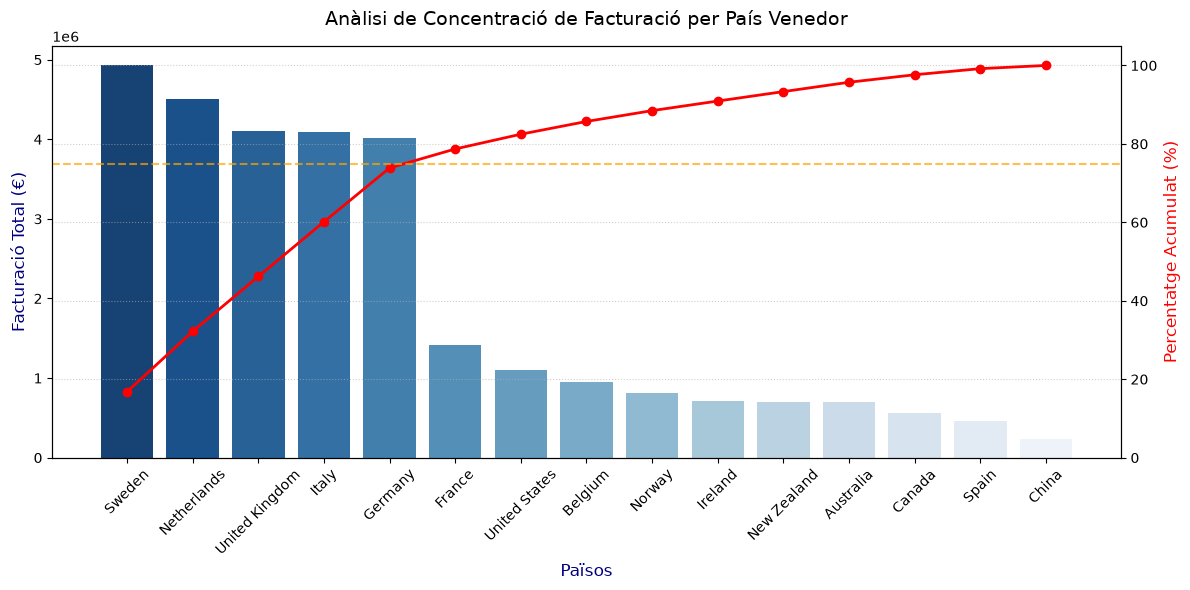

In [60]:
# Creem i inicialitzem la figura i l'eix principal del gràfic.
# Definim les dimensions del gràfic
fig, ax1 = plt.subplots(figsize=(12, 6))

# Eix 1: Barres de facturació per país
sns.barplot(
    data=df_pais,
    x="country",
    y="facturacio_total",
    ax=ax1,
    palette="Blues_r",
    hue="country",
    legend=False
)
# Etiqueta del primer eix vertical
ax1.set_ylabel("Facturació Total (€)", color="navy", fontsize=12)
# Etiqueta de l'eix horitzontal
ax1.set_xlabel("Països", color="navy", fontsize=12)
# Títol del gràfic
ax1.set_title(
    "Anàlisi de Concentració de Facturació per País Venedor", fontsize=14, pad=15
)
# Inclinem els valors de l'eix horitzontal per tal que no es solapin
ax1.tick_params(axis="x", rotation=45)

# Eix 2: Línia del percentatge acumulat
ax2 = ax1.twinx()
ax2.plot(
    df_pais["country"],
    df_pais["per_acumulat"],
    color="red",
    marker="o",
    linewidth=2,
    label="% Acumulat",
)
# Etiqueta del segon eix vertical
ax2.set_ylabel("Percentatge Acumulat (%)", color="red", fontsize=12)
ax2.set_ylim(0, 105)

# Línia de referència de l'80% (Regla de Pareto)
ax2.axhline(75, color="orange", linestyle="--", alpha=0.7, label="Llindar 80%")

# Grid del fons
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()



🟢**Interpretació**


### ***2. Estacionalitat de les vendes***

**» Existeix estacionalitat en les vendes?**

Passos orientatius:

1. Treballar amb dates de transacció.

2. Extreure la informació temporal rellevant (any i mes).

3. Calcular el volum total de vendes (suma de amount) per any i mes.

4. Comparar patrons temporals amb la comparació entre anys. Crea una taula tipus pivot.

5. Visualitzar l'evolució.

In [84]:
df_trans['any'] = df_trans['timestamp'].dt.year
df_trans['mes'] = df_trans['timestamp'].dt.month

df_grup = df_trans[df_trans['declined']==0].groupby(['any','mes'])['amount'].sum().to_frame()
df_grup.reset_index(inplace=True)
pivot_vendes = df_grup.pivot (index='mes', columns='any', values='amount')
noms_mesos = [
    "Gener",
    "Febrer",
    "Març",
    "Abril",
    "Maig",
    "Juny",
    "Juliol",
    "Agost",
    "Setembre",
    "Octubre",
    "Novembre",
    "Desembre",
]
pivot_vendes.index = [noms_mesos[i - 1] for i in pivot_vendes.index]
pivot_vendes



any,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Gener,221978.21,224451.27,222956.21,227411.90,222944.11,231702.95,243339.85,224709.53,228413.66,226393.73
Febrer,245780.13,248112.42,252303.71,245092.09,259807.32,248318.04,257434.31,235427.85,251422.67,249898.07
Març,253000.65,246634.37,237621.09,237099.83,276818.21,258872.56,250861.14,271978.12,241711.00,245792.02
Abril,245597.21,240833.04,251596.72,234246.30,242707.81,244251.90,259770.51,237165.49,241264.06,244769.15
Maig,248585.36,241306.84,240125.80,244448.97,242550.42,253699.74,239662.08,276262.60,261355.45,254122.62
Juny,232624.35,230577.43,240337.61,242769.22,241694.85,236410.96,234080.71,260082.37,232254.56,244370.81
Juliol,241252.27,237081.73,240576.35,231261.73,233513.25,240255.64,251450.91,233349.01,238652.72,230031.53
Agost,233797.97,235600.88,230225.76,228759.89,237070.53,232658.86,237051.75,245198.95,237981.15,236671.63
Setembre,227211.93,241530.84,230606.28,236768.38,232551.83,257964.96,245398.37,254316.72,234226.30,234226.89
Octubre,241722.74,250228.07,240875.48,253827.42,250595.22,258891.46,264897.72,256342.46,250946.37,254314.46


In [68]:
df_trans['any'] = df_trans['timestamp'].dt.year
df_trans['mes'] = df_trans['timestamp'].dt.month

# Use pivot_table to aggregate and reshape the data
pivot_table = pd.pivot_table(df_trans[df_trans['declined']==0],
                             values='amount',
                             index='any',
                             columns='mes',
                             aggfunc='sum',
                             fill_value=0)

display(pivot_table)

mes,1,2,3,4,5,6,7,8,9,10,11,12
any,,,,,,,,,,,,
2015,221978.21,245780.13,253000.65,245597.21,248585.36,232624.35,241252.27,233797.97,227211.93,241722.74,225568.41,234787.51
2016,224451.27,248112.42,246634.37,240833.04,241306.84,230577.43,237081.73,235600.88,241530.84,250228.07,234831.91,234364.26
2017,222956.21,252303.71,237621.09,251596.72,240125.80,240337.61,240576.35,230225.76,230606.28,240875.48,242562.33,249902.05
2018,227411.90,245092.09,237099.83,234246.30,244448.97,242769.22,231261.73,228759.89,236768.38,253827.42,240049.08,234419.07
2019,222944.11,259807.32,276818.21,242707.81,242550.42,241694.85,233513.25,237070.53,232551.83,250595.22,231857.36,253678.24
2020,231702.95,248318.04,258872.56,244251.90,253699.74,236410.96,240255.64,232658.86,257964.96,258891.46,221821.05,243677.58
2021,243339.85,257434.31,250861.14,259770.51,239662.08,234080.71,251450.91,237051.75,245398.37,264897.72,240242.32,240108.44
2022,224709.53,235427.85,271978.12,237165.49,276262.60,260082.37,233349.01,245198.95,254316.72,256342.46,230435.35,237818.73
2023,228413.66,251422.67,241711.00,241264.06,261355.45,232254.56,238652.72,237981.15,234226.30,250946.37,233083.92,235132.78


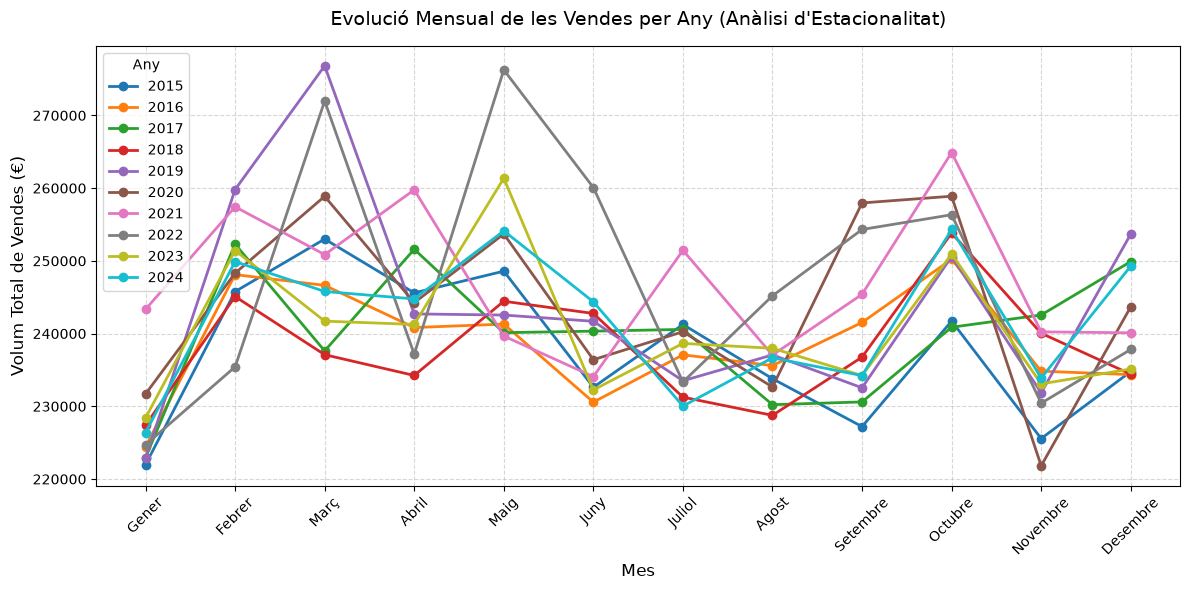

In [82]:
plt.figure(figsize=(12, 6))

# Dibuxem una línia per a cada any
for columna_any in pivot_vendes.columns:
    plt.plot(
        pivot_vendes.index,
        pivot_vendes[columna_any],
        marker="o",
        linewidth=2,
        label=str(columna_any),
    )

plt.title("Evolució Mensual de les Vendes per Any (Anàlisi d'Estacionalitat)", fontsize=14, pad=15)
plt.xlabel("Mes", fontsize=12)
plt.ylabel("Volum Total de Vendes (€)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="both", linestyle="--", alpha=0.5)
plt.legend(title="Any")
plt.tight_layout()
plt.show()

### ***3. Anàlisi de concentració i variabilitat de productes***

**Quins productes generen més ingressos i amb quina variabilitat?**

Passos orientatius:

1. Combinar transaccions, la taula pont i productes.

2. Calcular ingressos per producte amb un groupby, sum y sort.

3. Selecciona els top N productes: 15 per exemple.

4. Escollir una visualització adequada per analitzar dispersió.

In [98]:
df_merge = pd.merge(df_trans, df_trans_prod, left_on='id', right_on='id_transaction',how = 'inner')
df_merge = pd.merge(df_merge, df_prod, left_on='id_product', right_on='id',how = 'inner')
df_merge = df_merge[df_merge['declined']==0]
df_merge.head()

,id_x,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,...,id_y,product_name,price,colour,weight,warehouse_id,category,brand,cost,launch_date
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,16,the duel warden,180.91,#666666,3.0,WH-11,Home,NordHaus,101.11,2014-05-31
1,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,26,Stark Karstark,53.01,#898989,2.0,WH-21,Food,GreenFork,30.49,2013-02-15
2,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,87,sith Jade,96.26,#e2e2e2,1.5,WH-82,Food,Market&Co,66.36,2013-11-10
3,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,97,jinn Winterfell,65.25,#bababa,1.0,WH-92,Beauty,CareLab,26.25,2013-02-22
4,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.7573,-95.37960,...,11,Karstark Dorne,49.70,#141414,2.7,WH-6,Electronics,Nexa,34.45,2014-09-01


In [103]:
df_top_productes = df_merge.groupby(['id_y'])['amount'].sum().sort_values(ascending=False).head(15).reset_index(name="facturacio_total")

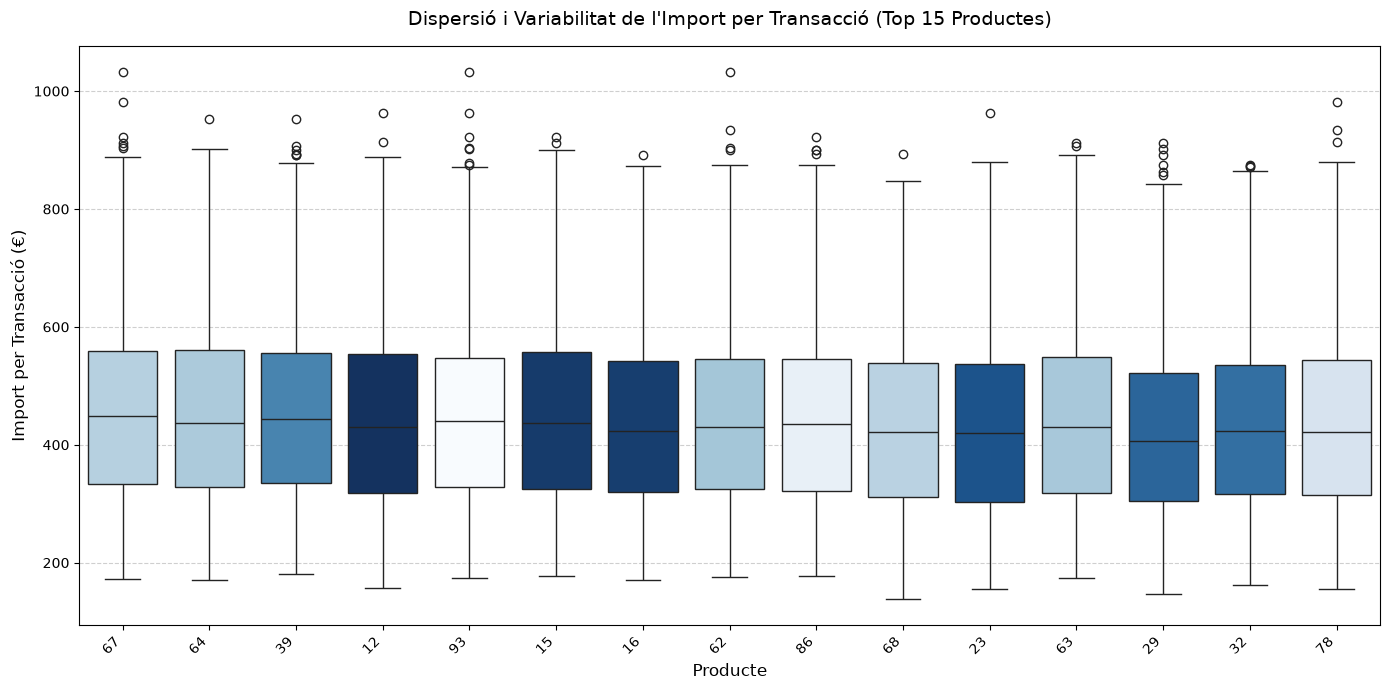

In [102]:
# Filtrem les transaccions individuals per incloure només els productes del Top 15
llista_top_15 = df_top_productes["id_y"].tolist()
df_top_15_transaccions = df_merge[df_merge["id_y"].isin(llista_top_15)]

plt.figure(figsize=(14, 7))

# Dibuixem el boxplot ordenat de major a menor ingressos totals
sns.boxplot(
    data=df_top_15_transaccions,
    x="id_y",
    y="amount",
    order=llista_top_15,
    palette="Blues_r",
    hue = "id_y",
    legend=False
)

plt.title(
    "Dispersió i Variabilitat de l'Import per Transacció (Top 15 Productes)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Producte", fontsize=12)
plt.ylabel("Import per Transacció (€)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### ***4. Anàlisi de patrons horaris***

**» Com varia l'activitat de venda per franges horàries al llarg dels anys? (patrons horaris)**

Passos orientatius:

1. Crear franges horàries a partir de l'hora: crea una funció i aplica-la utilitzant apply.

2. Construir una taula agregada utilitzant crosstab.

3. Visualitzar amb un heatmap.

In [109]:

def franges_horaries (hora):
  if hora >= 0 and hora < 6:
    franja = "00:00 - 06:00"
  elif hora >= 6 and hora < 12:
    franja = "06:00 - 12:00"
  elif hora >= 12 and hora < 18:
    franja = "12:00 - 18:00"
  else:
    franja = "18:00 - 23:59"
  return franja

df_trans['franja_horaria'] = df_trans['timestamp'].dt.hour.apply(franges_horaries)
df_trans['any'] = df_trans['timestamp'].dt.year
df_trans.head()


,id,card_id,business_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,...,tax_amount,shipping_amount,channel,campaign_id,device_type,is_international,decline_reason,distance_km,franja_horaria,any
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,"16, 26, 97, 87",4713,46.1999,1.43554,...,72.25,0.00,online,SUMMER_TRAVEL,mobile,0,,59.95,06:00 - 12:00,2024
1,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,"30, 11, 16, 81",2118,29.7573,-95.37960,...,22.47,0.00,store,SUMMER_TRAVEL,pos,1,,1157.10,12:00 - 18:00,2020
2,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,175.00,0,72,2115,53.5489,-113.50300,...,14.45,0.00,store,NO_CAMPAIGN,pos,0,,540.32,18:00 - 23:59,2017
3,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,158.55,0,18,3025,52.2084,5.69081,...,25.96,8.99,marketplace,WINTER_SALE,desktop,0,,28.52,18:00 - 23:59,2017
4,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,CcU-3358,b-2598,2023-09-23 04:51:43,317.97,0,"35, 33, 19",215,53.5535,-113.49900,...,26.25,0.00,store,NO_CAMPAIGN,pos,0,,539.82,00:00 - 06:00,2023


In [113]:
taula_horaria = pd.crosstab(df_trans['franja_horaria'], df_trans['any'],df_trans['amount'],aggfunc='sum')

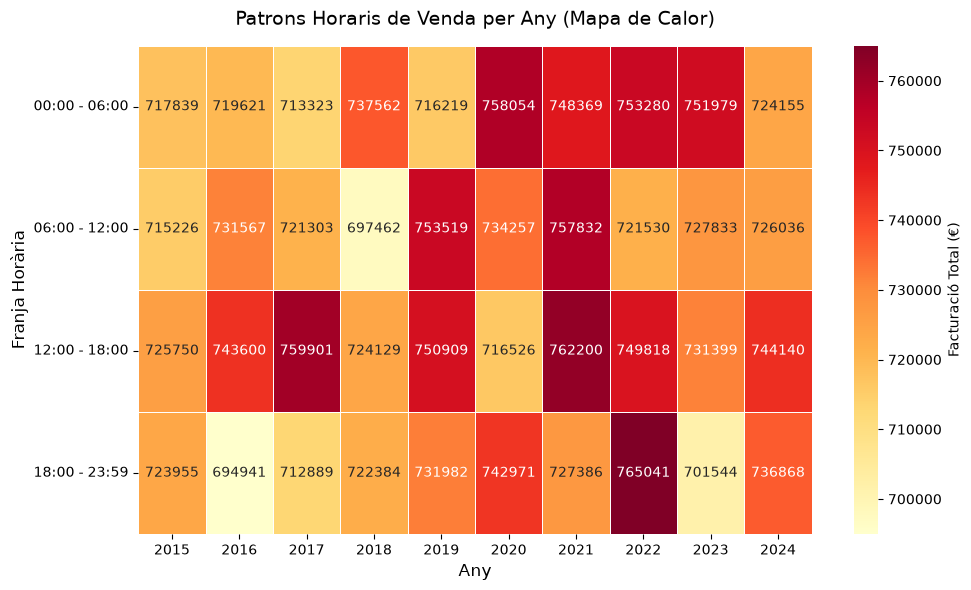

In [114]:
plt.figure(figsize=(10, 6))

# Dibuxem el mapa de calor
sns.heatmap(
    taula_horaria,
    annot=True,  # Mostra els valors dins de cada casella
    fmt=".0f",  # Format numèric sense decimals
    cmap="YlOrRd",  # Escala de colors (Groc -> Taronja -> Vermell)
    linewidths=0.5,
    cbar_kws={"label": "Facturació Total (€)"},
)

plt.title(
    "Patrons Horaris de Venda per Any (Mapa de Calor)", fontsize=14, pad=15
)
plt.xlabel("Any", fontsize=12)
plt.ylabel("Franja Horària", fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()